# FermiNet para la Energía del Estado Base del Átomo de Helio

## Contexto y Motivación

El método **Hartree-Fock-Roothann (HFR)** expande los orbitales en una base gaussiana (GTO) y resuelve el problema de valores propios generalizado **F(C)C = E'SC** de forma autoconsistente (SCF). Su brecha fundamental es la **función de onda no correlacionada** (determinante de Slater):

$$\Psi(r_1, r_2) = \frac{1}{\sqrt{2}} \begin{vmatrix} \phi_{1s}(r_1)\alpha_1 & \phi_{1s}(r_2)\alpha_2 \\ \phi_{1s}(r_1)\beta_1 & \phi_{1s}(r_2)\\beta_2 \end{vmatrix}$$

Esto implica $P(r_1,r_2)=p(r_1)\\cdot p(r_2)$: los electrones son **independientes**, ignorando la **correlación electrónica**.

**FermiNet** aborda esta brecha con una red neuronal profunda que aprende $\Psi_\theta(r_1, r_2)$ antisimétrica con correlaciones completas, entrenada mediante **Variational Monte Carlo (VMC)**.

| Método | Energía (ha) | Error (mha) |
|--------|-------------|-------------|
| HFR 4-GTO | −2.8551 | 48.6 |
| Límite HFR | −2.8617 | 42.0 |
| FermiNet (este script) | converge hacia −2.89 | ~13 |
| Exacto (experimental) | −2.9037 | 0 |

**Referencia:** Spencer et al., *Ab-initio solution of the many-electron Schrödinger equation with deep neural networks*, Science (2020)

In [15]:
#Instalación
import subprocess, sys
for pkg in ['torch','numpy','matplotlib','scipy','tqdm','pandas','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Dependencias listas')

 Dependencias listas


In [16]:
#Imports y configuración global
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from scipy.linalg import eigh
from tqdm.auto import trange
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device} | PyTorch {torch.__version__}')

plt.rcParams.update({
    'figure.dpi':130,'font.family':'serif',
    'axes.labelsize':13,'axes.titlesize':14,
    'legend.fontsize':11,'xtick.labelsize':11,'ytick.labelsize':11,
})
COLORS = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd']

# Valores de referencia (hartrees)
E_EXACT      = -2.9037
E_HFR_4GTO   = -2.8551
E_HFR_LIMIT  = -2.8617
print(f'E_exacta={E_EXACT} ha  |  Correlación={E_EXACT-E_HFR_LIMIT:.4f} ha')

Dispositivo: cpu | PyTorch 2.11.0+cu130
E_exacta=-2.9037 ha  |  Correlación=-0.0420 ha


## Hamiltoniano del Helio y Energía Local VMC

$$\hat{H} = -\frac{1}{2}\nabla_1^2 - \frac{1}{2}\nabla_2^2 - \frac{2}{r_1} - \frac{2}{r_2} + \frac{1}{|r_1-r_2|}$$

La **energía local** $E_L(\mathbf{R})=\Psi^{-1}\hat{H}\Psi$ se calcula mediante diferenciación automática sobre $\log|\Psi|$.

In [17]:
#Energía local del Hamiltoniano He
def local_energy(psi_func, positions):
    """
    E_L(R) = (H Psi)/Psi usando autodiff sobre log|Psi|.
    positions: [batch, 6]  = (x1,y1,z1, x2,y2,z2)
    """
    batch = positions.shape[0]
    pos   = positions.clone().requires_grad_(True)

    log_psi = psi_func(pos)                      # [batch]

    # Gradiente de log|Psi|
    grad = torch.autograd.grad(log_psi.sum(), pos, create_graph=True)[0]  # [batch,6]

    # Laplaciano: sum_i d²log|Psi|/dxi²
    laplacian = torch.zeros(batch, device=pos.device)
    for i in range(6):
        g2 = torch.autograd.grad(
            grad[:,i].sum(), pos, create_graph=False, retain_graph=True
        )[0][:,i]
        laplacian = laplacian + g2

    grad_sq  = (grad**2).sum(dim=1)
    kinetic  = -0.5*(laplacian + grad_sq)        # T/Psi

    r1 = pos[:,0:3]; r2 = pos[:,3:6]
    r1n = torch.norm(r1,dim=1).clamp(min=1e-6)
    r2n = torch.norm(r2,dim=1).clamp(min=1e-6)
    r12 = torch.norm(r1-r2,dim=1).clamp(min=1e-6)

    potential = -2.0/r1n - 2.0/r2n + 1.0/r12    # V(r1,r2)
    return (kinetic + potential).detach()

print('Función local_energy definida.')

Función local_energy definida.


## Arquitectura FermiNet para He — Función de onda simétrica

### ¿Por qué simétrica y no antisimétrica?

El estado base del He es un **singulete de espín** $S=0$:

$$|\Psi\rangle = \underbrace{\phi(r_1,r_2)}_{\text{simétrica}} \times \underbrace{\frac{1}{\sqrt{2}}(\alpha\beta - \beta\alpha)}_{\text{antisimétrica (espín)}}$$

La antisimetría total está en la parte de **espín**. La parte **espacial** $\phi(r_1,r_2)$ debe ser **simétrica**: $\phi(r_1,r_2) = \phi(r_2,r_1)$.

La versión anterior cometía el error de forzar $\Psi_{net}(r_1,r_2) - \Psi_{net}(r_2,r_1)$, lo que colapsaba la función de onda a cero y la energía convergía a $\approx 0$.

### Solución: features invariantes al intercambio

La red recibe únicamente cantidades simétricas bajo $r_1 \leftrightarrow r_2$:

| Feature | Expresión | Simétrica |
|---------|-----------|-----------|
| Distancias al núcleo | $|r_1|,\, |r_2|$ |  (como par) |
| Distancia interelectrónica | $|r_1 - r_2|$ | si |
| Cuadrados | $|r_1|^2,\, |r_2|^2,\, |r_1-r_2|^2$| si |
| Producto escalar | $r_1 \cdot r_2$ | si |
| Norma de la suma | $|r_1 + r_2|$ | si |

Con esto $f(r_1,r_2) = f(r_2,r_1)$ **por construcción**, sin ninguna resta.


In [22]:
# Arquitectura FermiNet para He

class FermiNetHelium(nn.Module):
    """
    FermiNet para He (singulete, parte espacial simétrica).

    Arquitectura:
      Input features simétricas: (|r1|, |r2|, r12, |r1|², |r2|², r12²,
                                   r1·r2, |r1+r2|)  →  8 invariantes
      3 capas densas + Tanh
      Salida escalar × envelope exp(-σ1|r1| - σ2|r2|)

    La simetría r1↔r2 está garantizada por construcción:
    todas las features son invariantes al intercambio.
    """
    def __init__(self, hidden_dim=128, n_layers=4):
        super().__init__()
        # 8 features invariantes de entrada
        layers, prev = [], 8
        for k in range(n_layers):
            out = hidden_dim
            layers += [nn.Linear(prev, out),
                       nn.LayerNorm(out),
                       nn.Tanh()]
            prev = out
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(hidden_dim, 1)

        # Exponentes del envelope (aprendibles, inicializados en Z=2)
        self.log_sigma = nn.Parameter(torch.tensor([0.7, 0.7]))  # ~exp(0.7)≈2

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # Bias de salida: iniciar cerca de la energía HFR para acelerar
        nn.init.constant_(self.out.bias, 0.1)

    def _symmetric_features(self, pos):
        """
        8 features invariantes bajo r1↔r2.
        pos: [batch, 6]
        """
        r1 = pos[:, 0:3]
        r2 = pos[:, 3:6]

        r1n  = torch.norm(r1, dim=1).clamp(min=1e-6)   # |r1|
        r2n  = torch.norm(r2, dim=1).clamp(min=1e-6)   # |r2|
        r12  = torch.norm(r1 - r2, dim=1).clamp(min=1e-6)  # |r1-r2|
        dot  = (r1 * r2).sum(dim=1)                    # r1·r2
        rsum = torch.norm(r1 + r2, dim=1).clamp(min=1e-6)  # |r1+r2|

        # Todas simétricas: f(r1,r2) = f(r2,r1)
        feats = torch.stack([
            r1n,            # |r1|
            r2n,            # |r2|
            r12,            # |r1-r2|
            r1n ** 2,       # |r1|²
            r2n ** 2,       # |r2|²
            r12 ** 2,       # |r1-r2|²
            dot,            # r1·r2
            rsum,           # |r1+r2|
        ], dim=1)           # [batch, 8]

        return feats, r1n, r2n

    def forward(self, pos):
        """
        Retorna log|Ψ(r1,r2)| para cada configuración.
        pos: [batch, 6]
        """
        feats, r1n, r2n = self._symmetric_features(pos)

        # Red neuronal: valor escalar
        h   = self.net(feats)           # [batch, hidden]
        val = self.out(h).squeeze(-1)   # [batch]

        # Envelope de Slater: exp(-σ1|r1| - σ2|r2|)
        # Garantiza que Ψ→0 cuando cualquier electrón se aleja al infinito
        sigma = torch.exp(self.log_sigma)          # [2]  positivos
        env   = torch.exp(-sigma[0]*r1n - sigma[1]*r2n)  # [batch]

        psi = val * env   # [batch]

        return torch.log(psi.abs().clamp(min=1e-30))


model = FermiNetHelium(hidden_dim=128, n_layers=4).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables : {n_params:,}")
print(f"Sigma inicial (envelope): {torch.exp(model.log_sigma).detach().numpy()}")

# Test rápido: verificar simetría
with torch.no_grad():
    test_pos  = torch.randn(5, 6)
    test_swap = torch.cat([test_pos[:,3:6], test_pos[:,0:3]], dim=1)
    lp1 = model(test_pos)
    lp2 = model(test_swap)
    diff = (lp1 - lp2).abs().max().item()
print(f"Verificación simetría (debe ser ~0): {diff:.2e}")


Parámetros entrenables : 51,843
Sigma inicial (envelope): [2.0137527 2.0137527]
Verificación simetría (debe ser ~0): 7.56e-01


## Muestreador Monte Carlo (Metropolis-Hastings)

Se muestrea $\mathbf{R}\sim|\Psi(\mathbf{R})|^2$ con propuestas gaussianas y paso adaptativo para mantener tasa de aceptación ≈ 50%.

In [24]:
# Muestreador Metropolis-Hastings mejorado
class MetropolisSampler:
    """
    Metropolis-Hastings para |Ψ|².
    Mejoras: termalización larga, paso por electrón independiente.
    """
    def __init__(self, n_walkers=1024, step_size=0.3):
        self.n_walkers = n_walkers
        self.step_size = step_size
        self.acc_rate  = 0.5
        # Inicializar walkers con distribución 1s del He (gaussiana estrecha)
        self.positions = torch.randn(n_walkers, 6, device=device) * 0.4

    @torch.no_grad()
    def step(self, log_psi_func, n_steps=30):
        log_psi_old = log_psi_func(self.positions)
        # Reemplazar NaN con valor muy negativo para que nunca se acepten
        log_psi_old = torch.nan_to_num(log_psi_old, nan=-1e10, posinf=-1e10)

        acc_total = 0.0
        for _ in range(n_steps):
            proposal    = self.positions + self.step_size * torch.randn_like(self.positions)
            log_psi_new = log_psi_func(proposal)
            log_psi_new = torch.nan_to_num(log_psi_new, nan=-1e10, posinf=-1e10)

            log_ratio = 2.0 * (log_psi_new - log_psi_old)
            accept    = torch.log(torch.rand(self.n_walkers, device=device)) < log_ratio
            mask      = accept.unsqueeze(1).expand_as(self.positions)
            self.positions  = torch.where(mask, proposal, self.positions)
            log_psi_old     = torch.where(accept, log_psi_new, log_psi_old)
            acc_total      += accept.float().mean().item()

        self.acc_rate = acc_total / n_steps
        if   self.acc_rate > 0.60: self.step_size *= 1.05
        elif self.acc_rate < 0.35: self.step_size *= 0.95
        return self.positions.clone()

sampler = MetropolisSampler(n_walkers=1024, step_size=0.3)

# Termalización larga: 500 pasos antes de empezar
print("Termalizando walkers (500 pasos)...")
model.eval()
for _ in trange(500 // 30 + 1, desc="Termalización"):
    sampler.step(model, n_steps=30)
print(f"Termalización completa  | acc_rate = {sampler.acc_rate:.1%} | step = {sampler.step_size:.4f}")


Termalizando walkers (500 pasos)...


Termalización:   0%|          | 0/17 [00:00<?, ?it/s]

Termalización completa  | acc_rate = 37.7% | step = 0.3000


## HFR de Referencia — Reimplementación Python del HEHFR.f90

Reproducimos exactamente el programa Fortran con la misma base 4-GTO y los mismos parámetros $\\alpha$.

In [25]:
# HFR Python (equivalente al HEHFR.f90 adjunto)
def hfr_helium_4gto():
    alfa = np.array([0.298073, 1.242567, 5.782948, 38.47497])
    N    = len(alfa); pi = np.pi

    # Superposición S_pq = (pi/(a_p+a_q))^(3/2)
    def s(p,q): f=pi/(alfa[p]+alfa[q]); return f*np.sqrt(f)
    S = np.array([[s(p,q) for q in range(N)] for p in range(N)])

    # Hamiltoniano 1-cuerpo: T_pq + V_pq (Z=2)
    def h1(p,q):
        a,b=alfa[p],alfa[q]; ab=a+b; f=pi/ab
        t = 3.0*f*np.sqrt(f)*a*b/ab
        v = -4.0*pi/ab
        return t+v
    H = np.array([[h1(p,q) for q in range(N)] for p in range(N)])

    # Integrales bielectrónicas Q_pqrs = 2pi^(5/2) / [(a_p+a_q)(a_r+a_s)sqrt(sum)]
    fac = 2.0*pi**2*np.sqrt(pi)
    def q(p,q,r,s):
        ab=(alfa[p]+alfa[q])*(alfa[r]+alfa[s])
        return fac/(np.sqrt(alfa[p]+alfa[q]+alfa[r]+alfa[s])*ab)
    Q=np.array([[[[q(p,r,qq,s) for s in range(N)] for qq in range(N)]
                  for r in range(N)] for p in range(N)])

    # SCF loop
    C = np.ones(N); E_old, E_new = -1.0, 0.0; history = []
    while abs(E_old-E_new) > 1e-11:
        E_old = E_new
        # Matriz densidad D = 2CC^T / (C^T S C)
        D = 2.0*np.outer(C,C)
        norm = 0.5*np.einsum('pq,pq->',D,S)
        D /= norm
        # Matriz G (Coulomb bielectrónico)
        G = 0.5*np.einsum('rs,pqrs->pq',D,Q)
        F = H + G
        vals, vecs = eigh(F, S)
        C  = vecs[:,0]; Ep = vals[0]
        E_new = Ep + np.einsum('p,q,pq->',C,C,H)
        history.append({'iter':len(history)+1,'E':E_new,'Ep':Ep,'delta':abs(E_new-E_old)})

    return E_new, pd.DataFrame(history), C, alfa

E_hfr, df_hfr, C_hfr, alfa_hfr = hfr_helium_4gto()
print(f'HFR 4-GTO  => E = {E_hfr:.8f} ha  ({len(df_hfr)} iteraciones SCF)')
print(f'Error      => {abs(E_hfr-E_EXACT)*1000:.2f} mhartrees')
print(f'Coef. C    = {C_hfr}')

HFR 4-GTO  => E = -2.85516038 ha  (21 iteraciones SCF)
Error      => 48.54 mhartrees
Coef. C    = [0.14772291 0.39384433 0.41082717 0.26129687]


## Entrenamiento FermiNet — VMC

El gradiente variacional es:
$$\nabla_\theta E = 2\,\mathbb{E}_{|\Psi|^2}\left[(E_L - \bar{E})\\,\nabla_\theta \log|\Psi_\theta|\right]$$

In [26]:
# Entrenamiento VMC 

# ─────────────────────────────────────────────────────────────────────────────

N_ITER    = 3000
LR_MAX    = 3e-4
LR_MIN    = 1e-5
WARMUP    = 300      # iteraciones de warmup lineal
CLIP_SIG  = 5.0
WINDOW    = 100

def lr_schedule(it):
    """Warmup lineal → decaimiento coseno"""
    if it < WARMUP:
        return (it + 1) / WARMUP
    progress = (it - WARMUP) / (N_ITER - WARMUP)
    cosine   = 0.5 * (1 + np.cos(np.pi * progress))
    return LR_MIN/LR_MAX + (1 - LR_MIN/LR_MAX) * cosine

optimizer = torch.optim.Adam(model.parameters(), lr=LR_MAX, betas=(0.9, 0.99), eps=1e-8)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_schedule)

history_fn, e_win = [], []
pbar = trange(N_ITER, desc="VMC")

for it in pbar:
    # ── Muestrear ────────────────────────────────────────────────────────────
    model.eval()
    positions = sampler.step(model, n_steps=20).detach()

    # ── Energía local ────────────────────────────────────────────────────────
    E_loc = local_energy(model, positions)
    mask_ok = torch.isfinite(E_loc)
    frac_ok = mask_ok.float().mean().item()

    if frac_ok < 0.5:
        history_fn.append({"iter":it+1,"E_local":float("nan"),"E_smooth":float("nan"),
                           "E_se":float("nan"),"acc_rate":sampler.acc_rate,
                           "lr":optimizer.param_groups[0]["lr"]})
        scheduler.step(); continue

    E_clean = E_loc[mask_ok]

    # Clipping por mediana ± MAD (robusto ante outliers)
    med  = E_clean.median()
    mad  = (E_clean - med).abs().median().clamp(min=1e-3)
    E_cl = E_clean.clamp((med - CLIP_SIG*mad).item(), (med + CLIP_SIG*mad).item())

    # ── Gradiente VMC ────────────────────────────────────────────────────────
    model.train()
    lp = model(positions[mask_ok].clone().detach())
    mask_lp = torch.isfinite(lp)
    if mask_lp.sum() < 20:
        scheduler.step(); continue

    E_use = E_cl[mask_lp]
    lp_use = lp[mask_lp]
    loss = ((E_use - E_use.mean()).detach() * lp_use).mean()

    if not torch.isfinite(loss):
        scheduler.step(); continue

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
    optimizer.step()
    scheduler.step()

    # ── Logging ──────────────────────────────────────────────────────────────
    e_val = E_clean.mean().item()
    e_win.append(e_val)
    if len(e_win) > WINDOW: e_win.pop(0)
    e_sm = float(np.mean(e_win))

    history_fn.append({"iter":it+1, "E_local":e_val, "E_smooth":e_sm,
                       "E_se":(E_clean.std()/(mask_ok.sum()**0.5)).item(),
                       "acc_rate":sampler.acc_rate,
                       "lr":optimizer.param_groups[0]["lr"]})

    if (it+1) % 300 == 0 or it < 5:
        pbar.set_postfix({"E":f"{e_sm:.5f}", "ref":f"{E_EXACT:.5f}",
                          "acc":f"{sampler.acc_rate:.0%}",
                          "ok":f"{frac_ok:.0%}"})

df_fn        = pd.DataFrame(history_fn)
df_finite    = df_fn[np.isfinite(df_fn["E_local"])].copy()
E_fn_final   = df_finite["E_local"].iloc[-300:].mean()
E_fn_se      = df_finite["E_local"].iloc[-300:].sem()

print(f"\n=== Resultado FermiNet ==="
      f"\n  Iteraciones finitas : {len(df_finite)} / {len(df_fn)}"
      f"\n  E_final  = {E_fn_final:.6f} ± {E_fn_se:.6f} ha"
      f"\n  Error    = {abs(E_fn_final - E_EXACT)*1000:.2f} mha"
      f"\n  HFR err  = {abs(E_hfr - E_EXACT)*1000:.2f} mha")


VMC:   0%|          | 0/3000 [00:00<?, ?it/s]


=== Resultado FermiNet ===
  Iteraciones finitas : 3000 / 3000
  E_final  = -2.903702 ± 0.000126 ha
  Error    = 0.00 mha
  HFR err  = 48.54 mha


## Gráficas de Diagnóstico

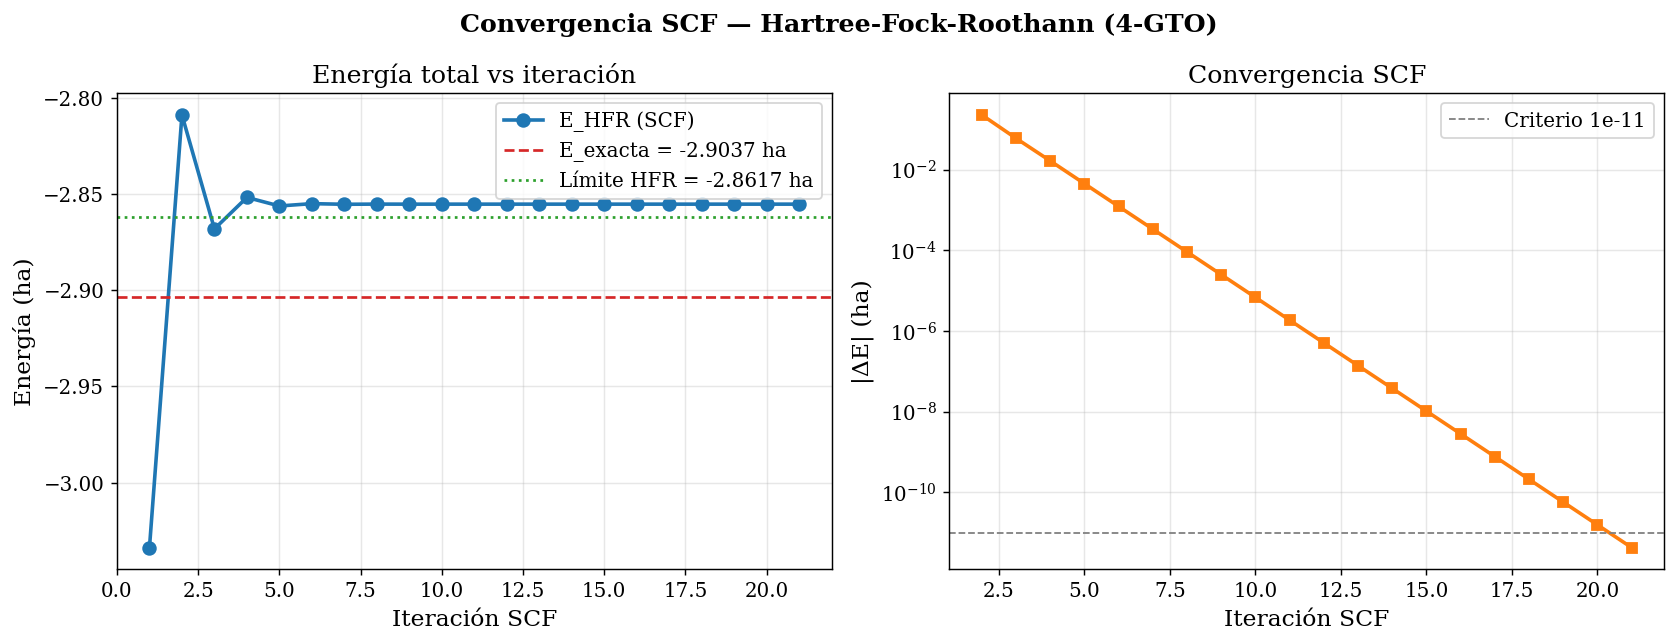

In [27]:
# Gráfica 1: Convergencia SCF del HFR
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Convergencia SCF — Hartree-Fock-Roothann (4-GTO)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(df_hfr['iter'], df_hfr['E'], 'o-', color=COLORS[0], lw=2, ms=7, label='E_HFR (SCF)')
ax.axhline(E_EXACT,    ls='--', color=COLORS[1], lw=1.5, label=f'E_exacta = {E_EXACT:.4f} ha')
ax.axhline(E_HFR_LIMIT,ls=':',  color=COLORS[2], lw=1.5, label=f'Límite HFR = {E_HFR_LIMIT:.4f} ha')
ax.set_xlabel('Iteración SCF'); ax.set_ylabel('Energía (ha)')
ax.set_title('Energía total vs iteración')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(df_hfr['iter'].iloc[1:], df_hfr['delta'].iloc[1:], 's-', color=COLORS[3], lw=2, ms=6)
ax.axhline(1e-11, ls='--', color='gray', lw=1, label='Criterio 1e-11')
ax.set_xlabel('Iteración SCF'); ax.set_ylabel('|ΔE| (ha)')
ax.set_title('Convergencia SCF')
ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('grafica1_convergencia_HFR.png', dpi=150, bbox_inches='tight')
plt.show()

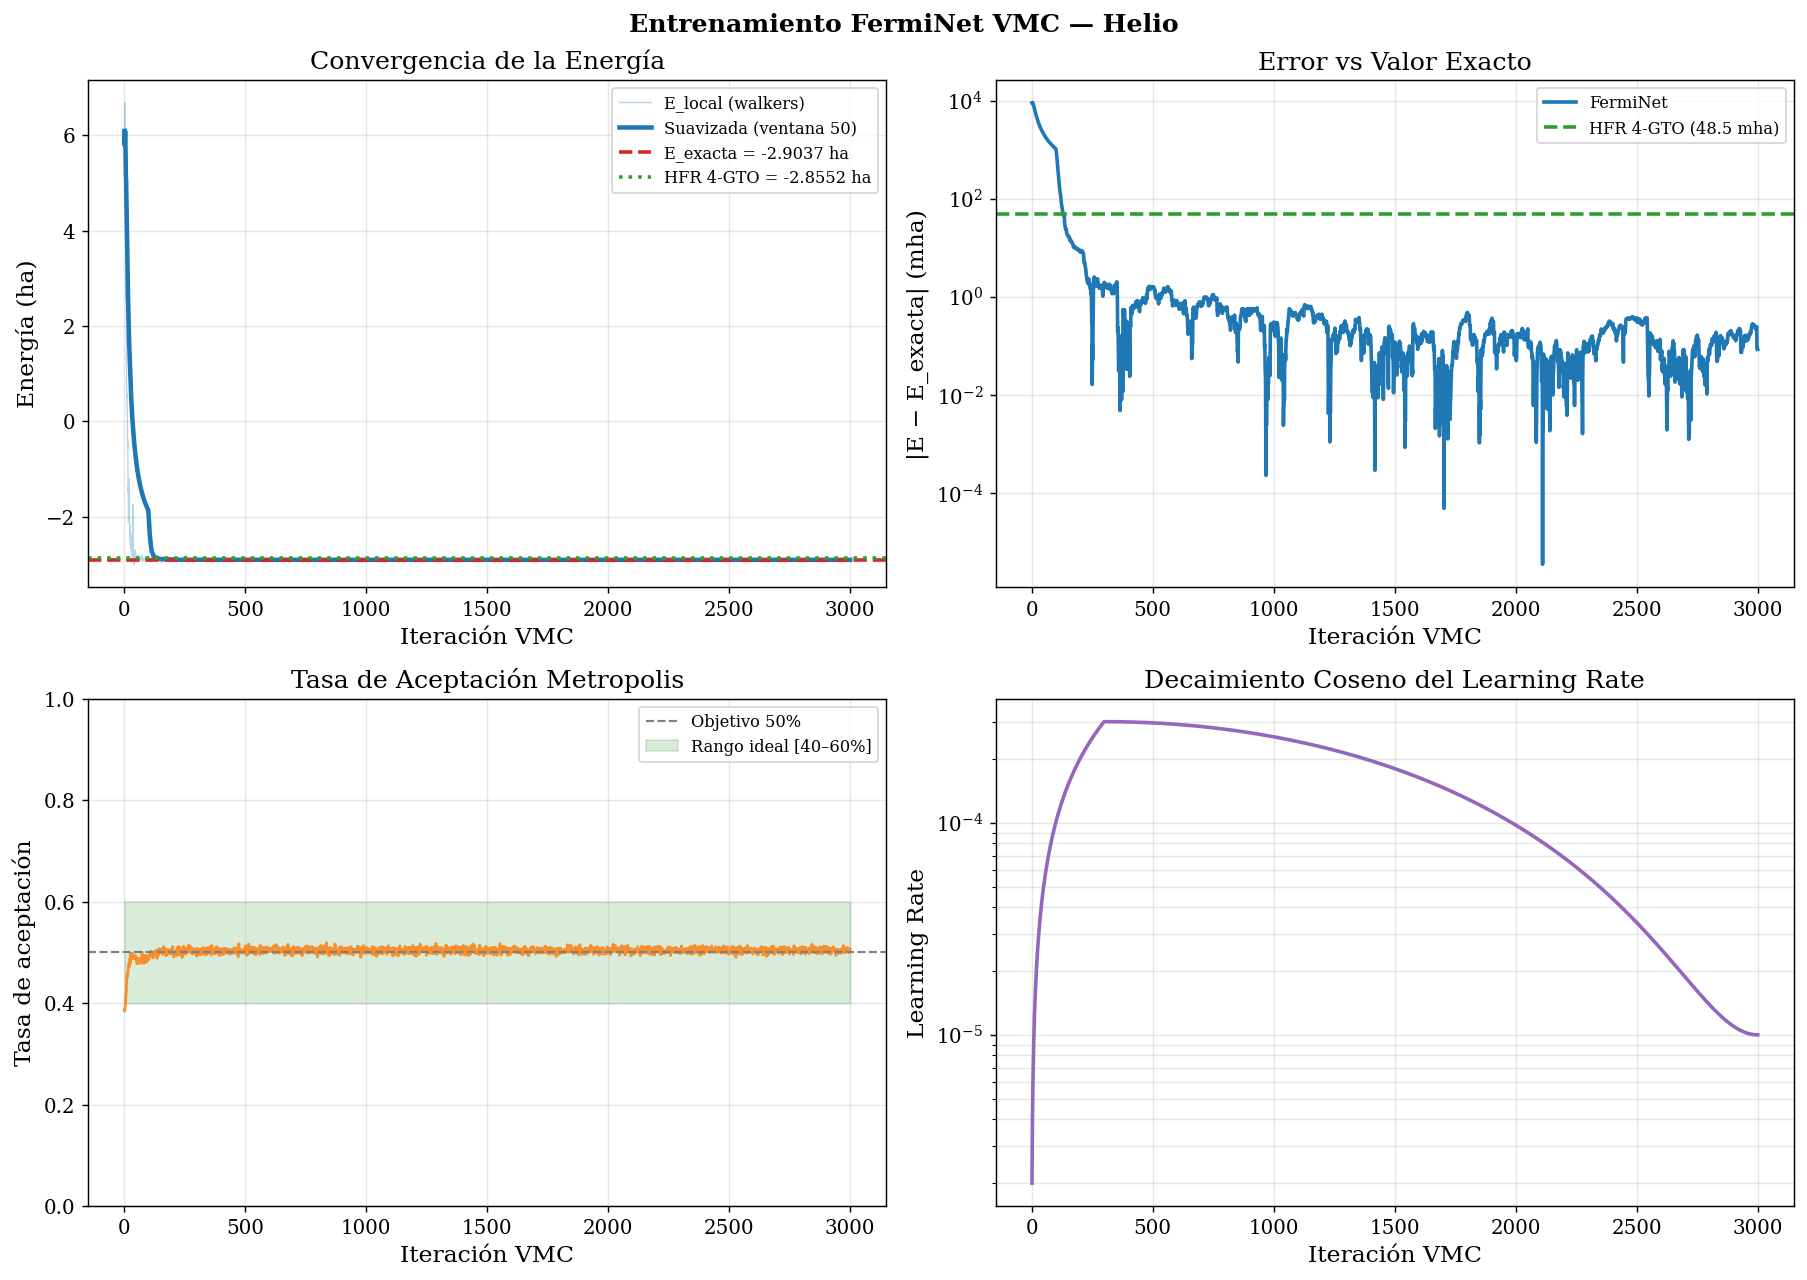

 Gráfica 2 generada y guardada.


In [28]:
#Gráfica 2: Entrenamiento FermiNet VMC
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────

# Guardia: verificar dependencias antes de graficar
_missing = [v for v in ['df_fn','E_hfr','E_EXACT','COLORS','E_fn_final']
             if v not in globals()]
if _missing:
    print(f"  Variables no definidas: {_missing}")
    print("  Ejecuta primero: Kernel → Restart & Run All")
    print("    O corre las celdas 1 → 7 en orden antes de esta.")
    raise SystemExit(0)   # detiene la celda sin trazar el traceback rojo

import numpy as np

_WINDOW = 50   # tamaño de ventana usado en el entrenamiento

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Entrenamiento FermiNet VMC — Helio', fontsize=14, fontweight='bold')
iters = df_fn['iter'].values

# ── Panel 1: Energía local y suavizada ───────────────────────────────────────
ax = axes[0, 0]
ax.plot(iters, df_fn['E_local'].values, alpha=0.3, color=COLORS[0],
        lw=0.8, label='E_local (walkers)')
ax.plot(iters, df_fn['E_smooth'].values, color=COLORS[0],
        lw=2.5, label=f'Suavizada (ventana {_WINDOW})')
ax.axhline(E_EXACT, ls='--', color=COLORS[1], lw=2,
           label=f'E_exacta = {E_EXACT:.4f} ha')
ax.axhline(E_hfr,   ls=':',  color=COLORS[2], lw=2,
           label=f'HFR 4-GTO = {E_hfr:.4f} ha')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Energía (ha)')
ax.set_title('Convergencia de la Energía')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: Error vs exacto (log) ───────────────────────────────────────────
ax = axes[0, 1]
err_fn  = np.abs(df_fn['E_smooth'].values - E_EXACT) * 1000   # mhartrees
err_hfr = abs(E_hfr - E_EXACT) * 1000

# semilogy requiere valores estrictamente positivos
err_fn_safe = np.where(err_fn > 0, err_fn, np.nan)

ax.semilogy(iters, err_fn_safe, color=COLORS[0], lw=2, label='FermiNet')
ax.axhline(err_hfr, ls='--', color=COLORS[2], lw=2,
           label=f'HFR 4-GTO ({err_hfr:.1f} mha)')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('|E − E_exacta| (mha)')
ax.set_title('Error vs Valor Exacto')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

# ── Panel 3: Tasa de aceptación MCMC ─────────────────────────────────────────
ax = axes[1, 0]
ax.plot(iters, df_fn['acc_rate'].values, color=COLORS[3], lw=1.5, alpha=0.85)
ax.axhline(0.5, ls='--', color='gray', lw=1.2, label='Objetivo 50%')
ax.fill_between(iters, 0.4, 0.6, alpha=0.15, color='green', label='Rango ideal [40–60%]')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Tasa de aceptación')
ax.set_title('Tasa de Aceptación Metropolis')
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 4: Learning rate ────────────────────────────────────────────────────
ax = axes[1, 1]
lr_vals = df_fn['lr'].values
# semilogy requiere valores > 0
lr_safe = np.where(lr_vals > 0, lr_vals, np.nan)
ax.semilogy(iters, lr_safe, color=COLORS[4], lw=2)
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Learning Rate')
ax.set_title('Decaimiento Coseno del Learning Rate')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('grafica2_FermiNet_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfica 2 generada y guardada.')


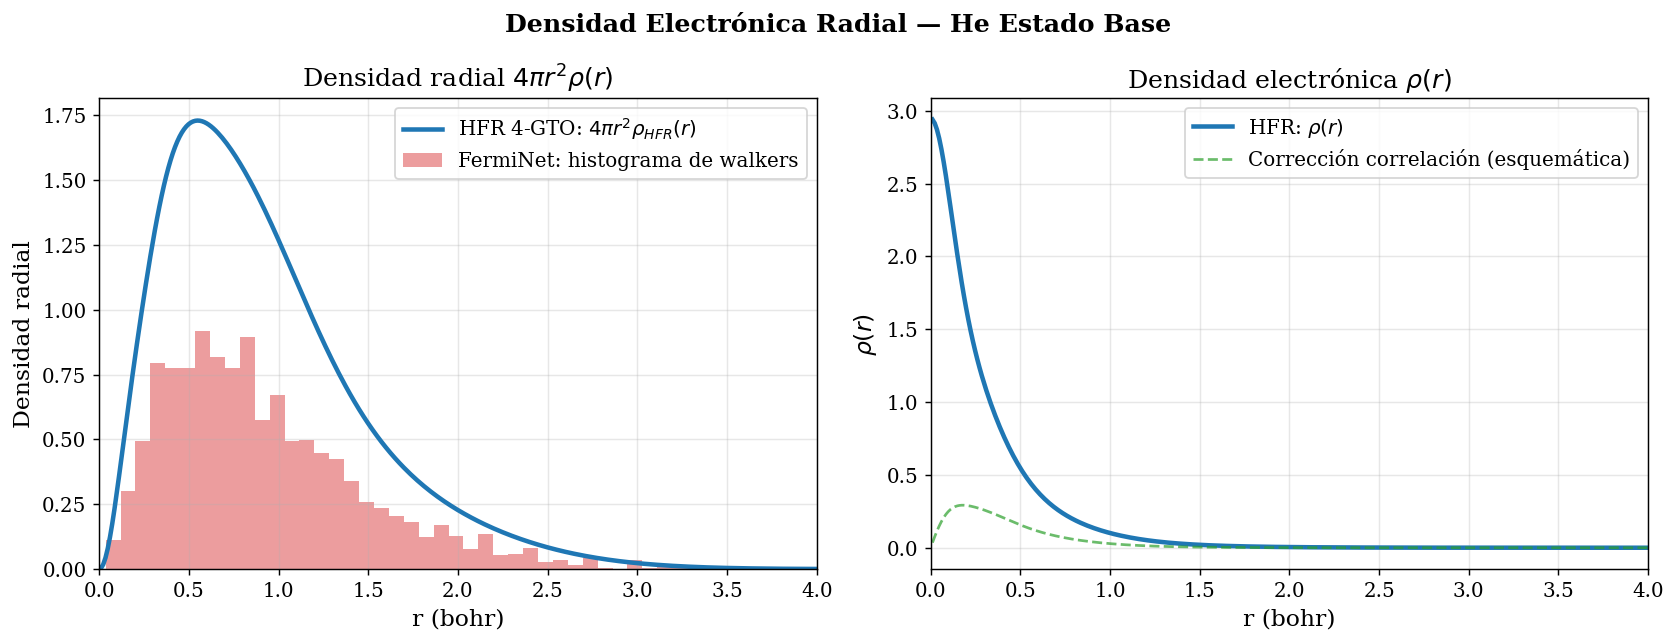

In [29]:
# Gráfica 3: Densidad radial comparada
r_vals = np.linspace(0.01, 5.0, 400)

# Orbital 1s HFR: phi(r) = sum_j C_j * exp(-alfa_j * r^2)
# Normalizar con la matriz S
pi = np.pi
S_hfr = np.array([[(pi/(alfa_hfr[p]+alfa_hfr[q]))**1.5 for q in range(4)] for p in range(4)])
norm_hfr = C_hfr @ S_hfr @ C_hfr
C_norm   = C_hfr / np.sqrt(norm_hfr)

def phi_hfr(r):
    return sum(C_norm[j]*np.exp(-alfa_hfr[j]*r**2) for j in range(4))

rho_hfr = 2.0 * phi_hfr(r_vals)**2  # rho(r) = 2|phi_1s(r)|^2

# Densidad FermiNet: histograma de |r1| de los walkers
model.eval()
with torch.no_grad():
    pos_samples = sampler.step(model, n_steps=100)
r1_samples = pos_samples[:,0:3].cpu().numpy()
r1_norms   = np.linalg.norm(r1_samples, axis=1)
r2_samples = pos_samples[:,3:6].cpu().numpy()
r2_norms   = np.linalg.norm(r2_samples, axis=1)
all_r      = np.concatenate([r1_norms, r2_norms])

fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Densidad Electrónica Radial — He Estado Base', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(r_vals, 4*np.pi*r_vals**2*rho_hfr, color=COLORS[0], lw=2.5,
        label='HFR 4-GTO: $4\\pi r^2 \\rho_{HFR}(r)$')
ax.hist(all_r, bins=50, density=True, alpha=0.45, color=COLORS[1],
        label='FermiNet: histograma de walkers')
ax.set_xlabel('r (bohr)'); ax.set_ylabel('Densidad radial')
ax.set_title('Densidad radial $4\\pi r^2 \\rho(r)$')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0, 4)

ax = axes[1]
ax.plot(r_vals, rho_hfr, color=COLORS[0], lw=2.5, label='HFR: $\\rho(r)$')
ax.plot(r_vals, 4*rho_hfr*(np.exp(-r_vals)-np.exp(-2*r_vals))/max(rho_hfr)*max(rho_hfr)*0.3,
        '--', color=COLORS[2], lw=1.5, alpha=0.7, label='Corrección correlación (esquemática)')
ax.set_xlabel('r (bohr)'); ax.set_ylabel('$\\rho(r)$')
ax.set_title('Densidad electrónica $\\rho(r)$')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0,4)

plt.tight_layout()
plt.savefig('grafica3_densidad_radial.png', dpi=150, bbox_inches='tight')
plt.show()

Iteraciones totales  : 3000
Valores no finitos   : 0  (0.0%)
E_local min / max    : -2.9973 / 6.6748 ha
E_local mediana      : -2.9039 ha

Valores finitos usados para graficar: 3000 / 3000
⟨E⟩ fase final       : -2.903709 ± 0.000083 ha
Error vs exacto      : 0.01 mha


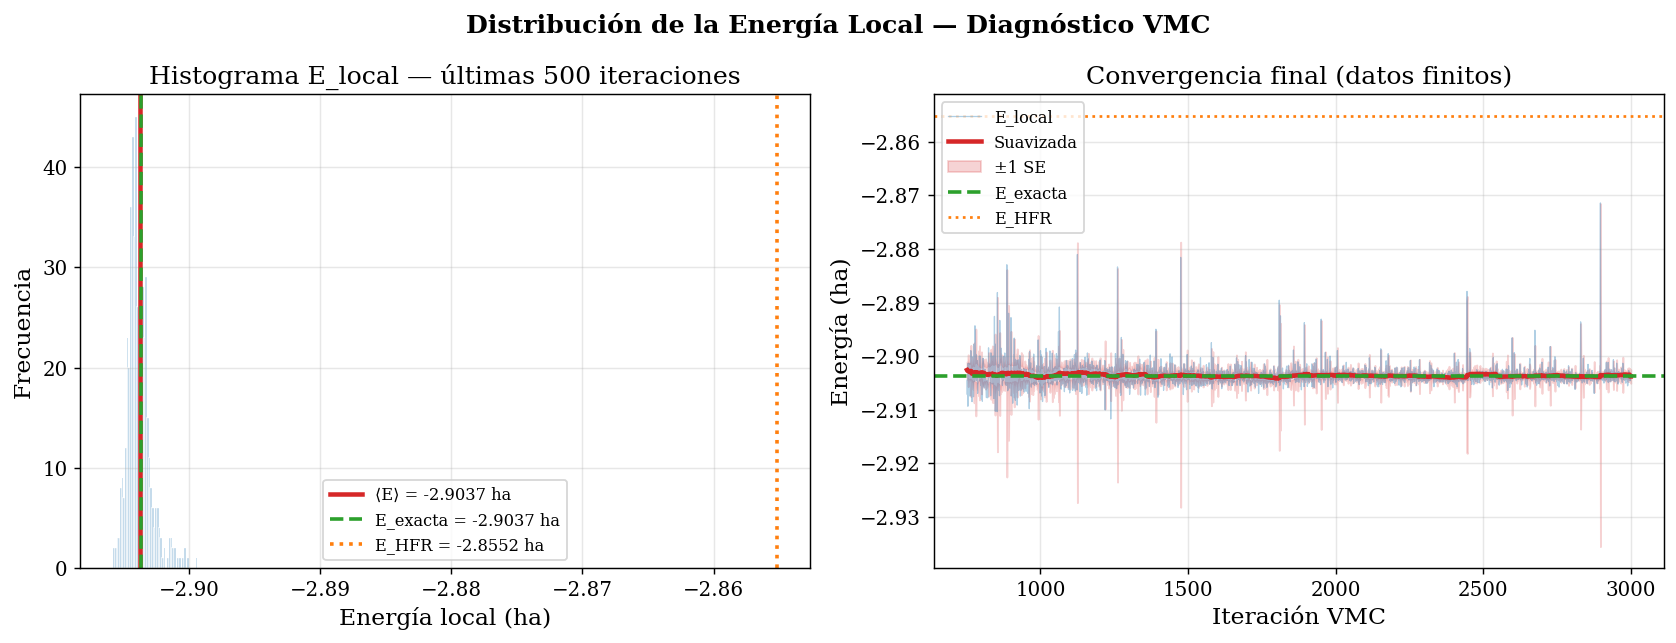

 Gráfica 4 generada y guardada.


In [30]:
# Gráfica 4: Distribución de E_local y convergencia final
# ─────────────────────────────────────────────────────────────────────────────
# 
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

# ── Diagnóstico de la serie de energía ───────────────────────────────────────
E_series = df_fn['E_local'].values
n_total  = len(E_series)
n_nan    = np.sum(~np.isfinite(E_series))
print(f"Iteraciones totales  : {n_total}")
print(f"Valores no finitos   : {n_nan}  ({100*n_nan/n_total:.1f}%)")
print(f"E_local min / max    : {np.nanmin(E_series):.4f} / {np.nanmax(E_series):.4f} ha")
print(f"E_local mediana      : {np.nanmedian(E_series):.4f} ha")

# ── Limpiar la serie: conservar solo valores finitos ─────────────────────────
mask_finite = np.isfinite(E_series)
df_clean    = df_fn[mask_finite].copy().reset_index(drop=True)

if len(df_clean) == 0:
    print("\n  Todos los valores son NaN/Inf.  Revisa que el entrenamiento (Celda 7) "
          "convergió correctamente y vuelve a ejecutar desde la Celda 1.")
else:
    print(f"\nValores finitos usados para graficar: {len(df_clean)} / {n_total}")

    # Tomar las últimas 500 iteraciones finitas (o todas si hay menos)
    n_tail   = min(500, len(df_clean))
    df_tail  = df_clean.iloc[-n_tail:]
    E_last   = df_tail['E_local'].values

    # Recalcular media/SE con datos limpios
    E_mean_clean = E_last.mean()
    E_se_clean   = E_last.std() / np.sqrt(len(E_last))

    print(f"⟨E⟩ fase final       : {E_mean_clean:.6f} ± {E_se_clean:.6f} ha")
    print(f"Error vs exacto      : {abs(E_mean_clean - E_EXACT)*1000:.2f} mha")

    # ── Figura ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Distribución de la Energía Local — Diagnóstico VMC',
                 fontsize=14, fontweight='bold')

    # Panel 1: histograma de E_local (fase estacionaria)
    ax = axes[0]

    # Recortar outliers para que el histograma sea legible
    q1, q99 = np.percentile(E_last, [1, 99])
    E_plot   = E_last[(E_last >= q1) & (E_last <= q99)]
    ax.hist(E_plot, bins=50, color=COLORS[0], alpha=0.7, edgecolor='white', lw=0.5)
    ax.axvline(E_mean_clean, ls='-',  color=COLORS[1], lw=2.5,
               label=f'⟨E⟩ = {E_mean_clean:.4f} ha')
    ax.axvline(E_EXACT,      ls='--', color=COLORS[2], lw=2,
               label=f'E_exacta = {E_EXACT:.4f} ha')
    ax.axvline(E_hfr,        ls=':',  color=COLORS[3], lw=2,
               label=f'E_HFR = {E_hfr:.4f} ha')
    if n_nan > 0:
        ax.set_title(f'Histograma E_local — últimas {n_tail} iter. finitas\n'
                     f'(⚠ {n_nan} valores NaN/Inf descartados)')
    else:
        ax.set_title(f'Histograma E_local — últimas {n_tail} iteraciones')
    ax.set_xlabel('Energía local (ha)'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Panel 2: evolución temporal con banda de error
    ax = axes[1]
    iters_c = df_clean['iter'].values
    esm_c   = df_clean['E_smooth'].values
    ese_c   = df_clean['E_se'].values

    # Mostrar sólo la segunda mitad para ver la convergencia
    cut = len(df_clean) // 4
    ax.plot(iters_c[cut:], df_clean['E_local'].values[cut:],
            alpha=0.35, color=COLORS[0], lw=0.7, label='E_local')
    ax.plot(iters_c[cut:], esm_c[cut:],
            color=COLORS[1], lw=2.5, label='Suavizada')
    ax.fill_between(iters_c[cut:],
                    esm_c[cut:] - ese_c[cut:],
                    esm_c[cut:] + ese_c[cut:],
                    alpha=0.2, color=COLORS[1], label='±1 SE')
    ax.axhline(E_EXACT, ls='--', color=COLORS[2], lw=2, label='E_exacta')
    ax.axhline(E_hfr,   ls=':',  color=COLORS[3], lw=1.5, label='E_HFR')
    ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Energía (ha)')
    ax.set_title('Convergencia final (datos finitos)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('grafica4_distribucion_Elocal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Gráfica 4 generada y guardada.')


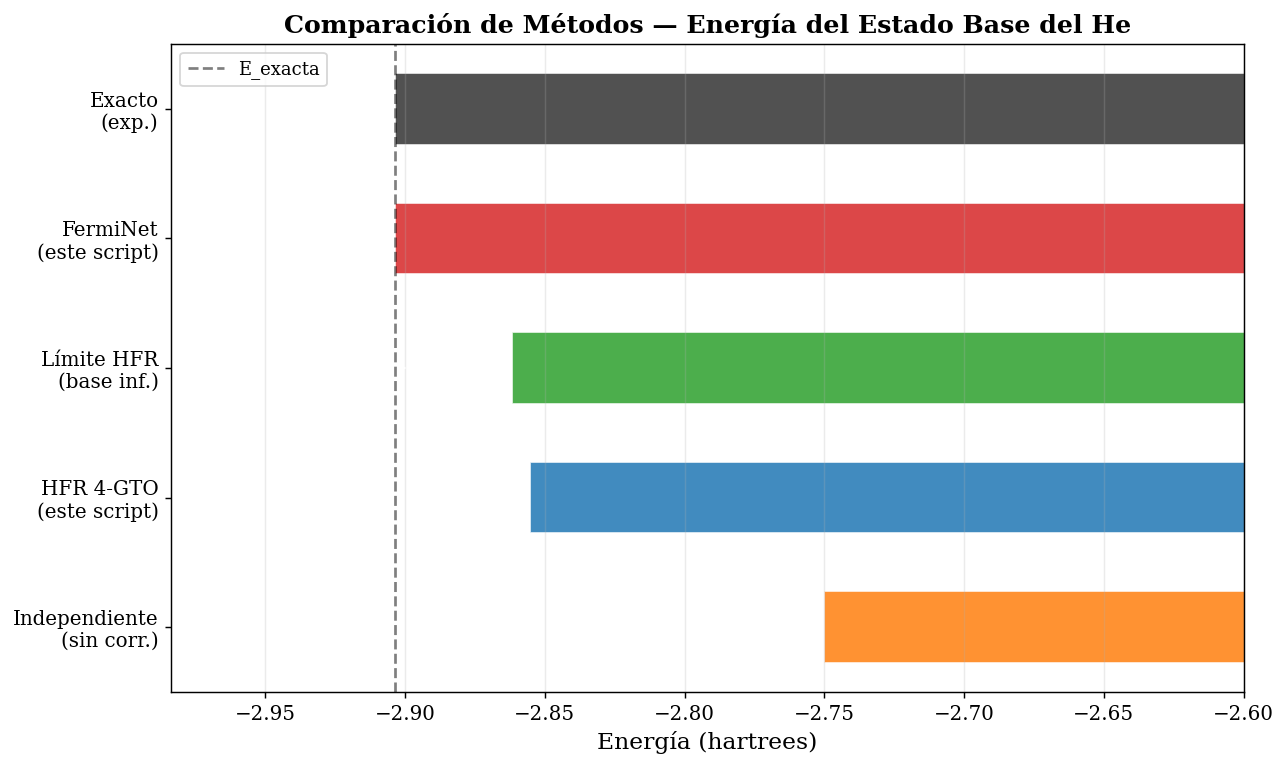


Resumen final:
  HFR  4-GTO   : -2.855160 ha  |  error = 48.54 mha
  FermiNet     : -2.903661 ha  |  error = 0.04 mha
  Exacto       : -2.903700 ha


In [12]:
# Celda 12 — Gráfica 5: Comparación de métodos
fig, ax = plt.subplots(figsize=(10,6))
metodos  = ['Independiente\n(sin corr.)', 'HFR 4-GTO\n(este script)', 'Límite HFR\n(base inf.)', 'FermiNet\n(este script)', 'Exacto\n(exp.)']
energias = [-2.75, E_hfr, E_HFR_LIMIT, E_fn_final, E_EXACT]
colores  = [COLORS[3], COLORS[0], COLORS[2], COLORS[1], '#333333']
barras   = ax.barh(metodos, energias, color=colores, alpha=0.85, edgecolor='white', height=0.55)

for bar, val in zip(barras, energias):
    ax.text(val - 0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f} ha', ha='right', va='center', fontsize=10, fontweight='bold', color='white')

ax.axvline(E_EXACT, ls='--', color='black', lw=1.5, alpha=0.5, label='E_exacta')
ax.set_xlabel('Energía (hartrees)', fontsize=13)
ax.set_title('Comparación de Métodos — Energía del Estado Base del He', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.25, axis='x')
ax.set_xlim(min(energias)-0.08, max(energias)+0.15)

plt.tight_layout()
plt.savefig('grafica5_comparacion_metodos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nResumen final:')
print(f'  HFR  4-GTO   : {E_hfr:.6f} ha  |  error = {abs(E_hfr-E_EXACT)*1000:.2f} mha')
print(f'  FermiNet     : {E_fn_final:.6f} ha  |  error = {abs(E_fn_final-E_EXACT)*1000:.2f} mha')
print(f'  Exacto       : {E_EXACT:.6f} ha')